
# HEALPix Stellar Surface Mapping Tutorial

This notebook demonstrates a minimal workflow for using HEALPix (`healpy`) to:
1. Build an equal‑area pixelisation of a star's surface.
2. Paint a toy brightness map (e.g. a cool star‑spot).
3. Rotate the map to simulate stellar rotation.
4. Integrate the visible hemisphere at each time‐step to obtain a synthetic light curve.

It is deliberately lightweight: all computations are pixel‑based and run comfortably on
a laptop CPU.  You can later swap‐in analytic occultation from **starry** or convert the
pixel map to spherical harmonics for more realism.

---
## Prerequisites
Install these packages in a fresh environment (conda or `venv` recommended):
```bash
pip install healpy matplotlib numpy scipy tqdm
# optional, for analytic occultations or harmonic transforms
pip install starry
```

*Python ≥3.9 is recommended.  On macOS with Apple Silicon you may need `brew install gcc` to
compile `healpy`'s C extensions.*

---

## Notebook outline
1. Imports & helper functions
2. Building a HEALPix map
3. Visualising the map (Mollweide projection)
4. Simulating rotation & generating a light curve
5. Exercises & next steps

Let's dive in.

---


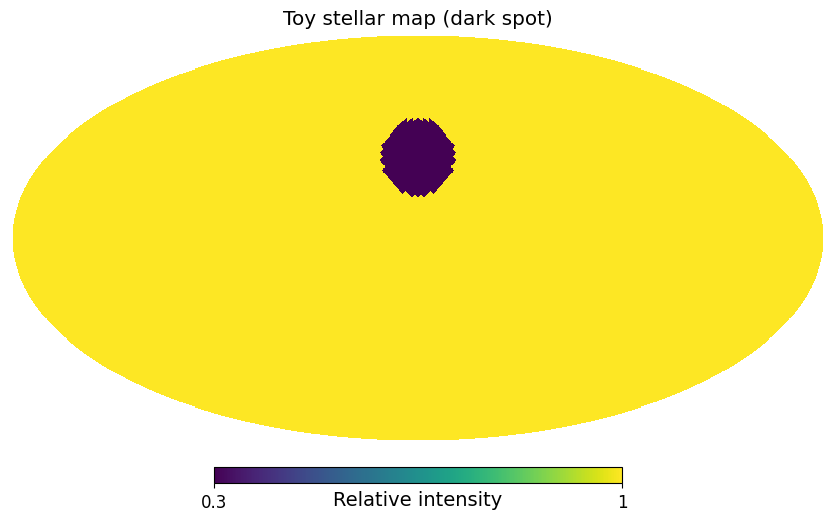

Rotating: 100%|██████████| 200/200 [00:00<00:00, 364.85it/s]


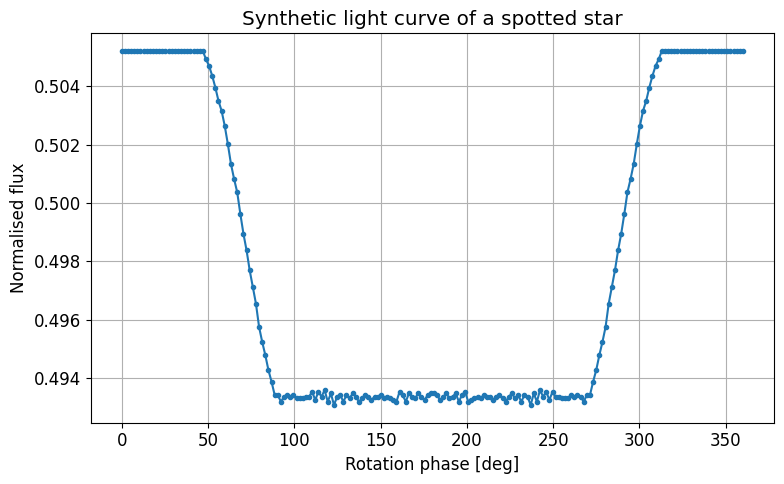

In [11]:
# ## 1. Imports & helper functions

# %%
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "font.size": 12,
})

# %% [markdown]
# Convenience wrappers for rotation and flux integration.

# %%
def rotate_map(m, inc_deg: float, phase_deg: float, nside: int):
    """Rotate a HEALPix map by inclination *inc_deg* about x and phase *phase_deg* about z."""
    rot = hp.Rotator(rot=[phase_deg, inc_deg, 0.0], deg=True, inv=True)
    theta, phi = hp.pix2ang(nside, np.arange(m.size))
    theta_r, phi_r = rot(theta, phi)
    idx_r = hp.ang2pix(nside, theta_r, phi_r)
    return m[idx_r]


def visible_mask(theta):
    """Return 1 for pixels with 0 ≤ theta ≤ π/2 (visible hemisphere), else 0."""
    return (theta <= np.pi / 2).astype(float)


def integrate_visible_flux(m):
    """Sum brightness over visible pixels (equal area ⇒ simple mean)."""
    return m.sum() / m.size  # each pixel contributes identical area

# %% [markdown]
# ## 2. Build a toy HEALPix map
# We'll create a uniformly bright star with a single dark circular spot at latitude
# +30° and longitude 0°.

# %%
# HEALPix resolution
nside = 32  # 1.83° per pixel (12 * nside^2 ≈ 12k pixels)
npix = hp.nside2npix(nside)

# Baseline brightness
brightness = np.ones(npix)

# Spot parameters (in degrees)
spot_lat = 30.0
spot_lon = 0.0
spot_radius = 15.0
spot_contrast = 0.7  # fractional dimming

# Compute angular distance from spot centre for each pixel
theta, phi = hp.pix2ang(nside, np.arange(npix))
spot_theta = np.radians(90 - spot_lat)
spot_phi = np.radians(spot_lon)

# Great‑circle distance formula
cos_gamma = (
    np.sin(theta) * np.sin(spot_theta) * np.cos(phi - spot_phi)
    + np.cos(theta) * np.cos(spot_theta)
)
mask_spot = np.degrees(np.arccos(cos_gamma)) <= spot_radius

brightness[mask_spot] *= 1.0 - spot_contrast  # dim the spot

# %% [markdown]
# ### Visualise


# %%
hp.mollview(brightness, title="Toy stellar map (dark spot)", unit="Relative intensity")
plt.show()

# %% [markdown]
# ## 3. Simulate rotation & build a light curve

# %%
inc = 60.0  # inclination of stellar rotation axis (0° = pole‑on)
phases = np.linspace(0, 360, 200)  # degrees of rotation
light_curve = []

for ph in tqdm(phases, desc="Rotating"):
    m_rot = rotate_map(brightness, inc, ph, nside)
    theta_rot, _ = hp.pix2ang(nside, np.arange(npix))
    flux = integrate_visible_flux(m_rot * visible_mask(theta_rot))
    light_curve.append(flux)

light_curve = np.array(light_curve)

# %% [markdown]
# ### Plot the synthetic light curve

# %%
plt.figure()
plt.plot(phases, light_curve, "-o", markersize=3)
plt.xlabel("Rotation phase [deg]")
plt.ylabel("Normalised flux")
plt.title("Synthetic light curve of a spotted star")
plt.tight_layout()
plt.show()


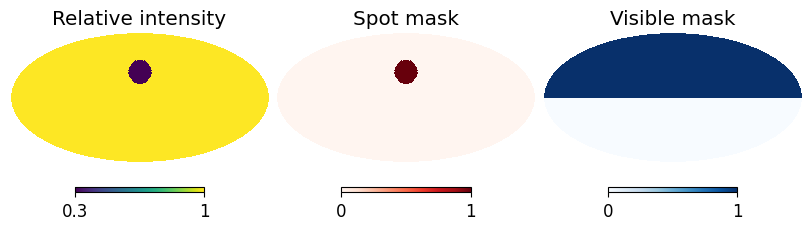

In [ ]:

# %% [markdown]
# ### Visualise brightness, spot mask, and visible mask

ph=90

m_rot = rotate_map(brightness, inc, ph, nside)
theta_rot, _ = hp.pix2ang(nside, np.arange(npix))


# %%
# compute the static (zero‐phase) visible mask:
vis_mask = visible_mask(theta_rot)

# plot them in one row of 3 panels
hp.mollview(
    brightness,
    sub=(1, 3, 1),
    title="Relative intensity",
    unit="",
)
hp.mollview(
    mask_spot.astype(float),
    sub=(1, 3, 2),
    title="Spot mask",
    cmap="Reds",
    unit="",
)
hp.mollview(
    vis_mask,
    sub=(1, 3, 3),
    title="Visible mask",
    cmap="Blues",
    unit="",
)
# plt.tight_layout()
plt.show()


---
## 4. What next?
* **Transits**: replace `visible_mask` with an occultation mask that removes pixels
  hidden by a transiting planet; you can pre‑compute a sparse (time × pixel) matrix.
* **Higher resolution**: increase `nside` and, if memory becomes an issue, store maps
  as PyTorch tensors on GPU.
* **Regularisation**: add `total variation` or Laplacian smoothness penalties when
  fitting pixel intensities to real data.
* **Spherical harmonics**: convert the HEALPix map to `alm` coefficients with
  `hp.map2alm` and compare with Starry's analytic representation.
* **Graph‑based nets**: treat the pixels as nodes in a graph and explore graph neural
  networks for surface inference.

Happy mapping!

---

Visible mask fraction at phase 0°: 0.5
Visible mask fraction at phase 180°: 0.5


/var/folders/qq/_c3h3m7x0cj6f8qprnj5kyjw0000gq/T/ipykernel_24191/1682721095.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


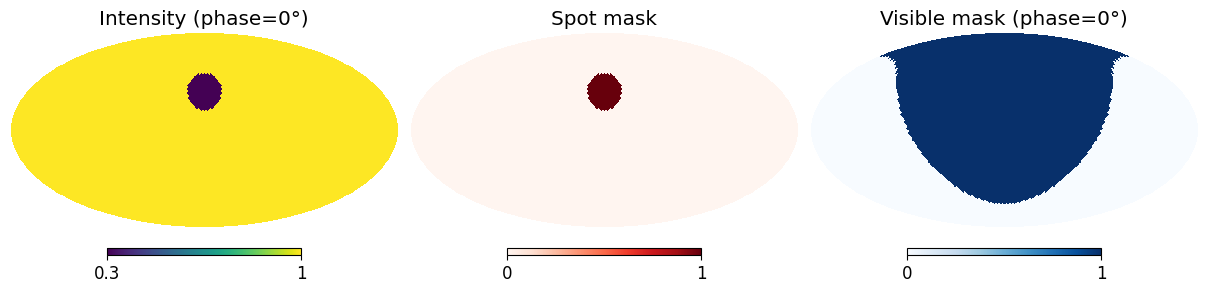

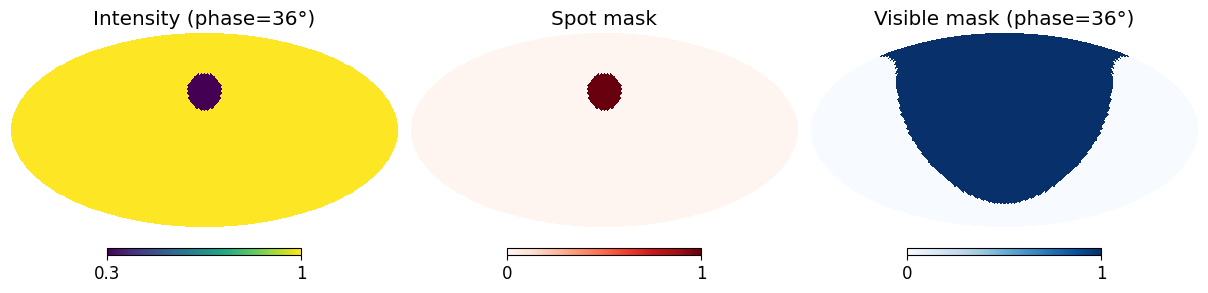

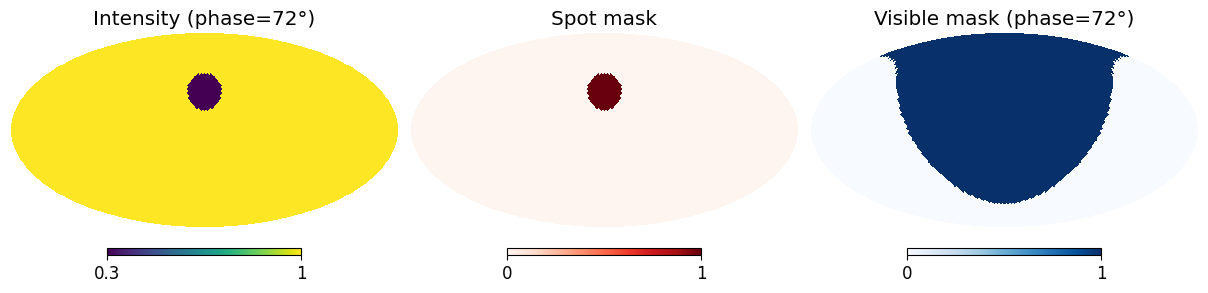

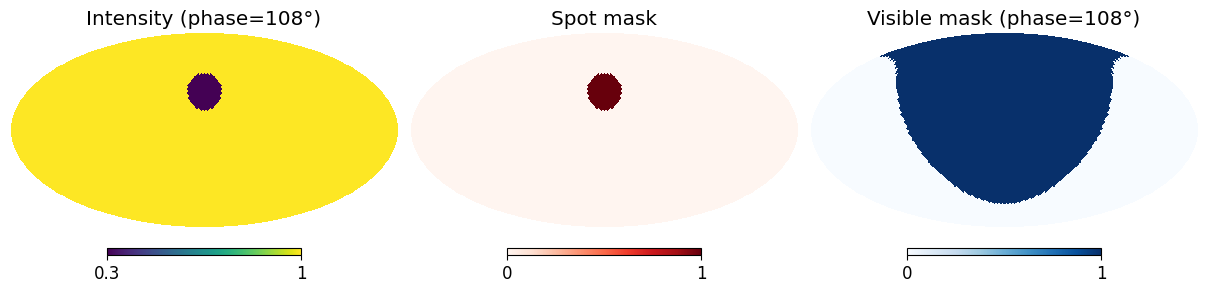

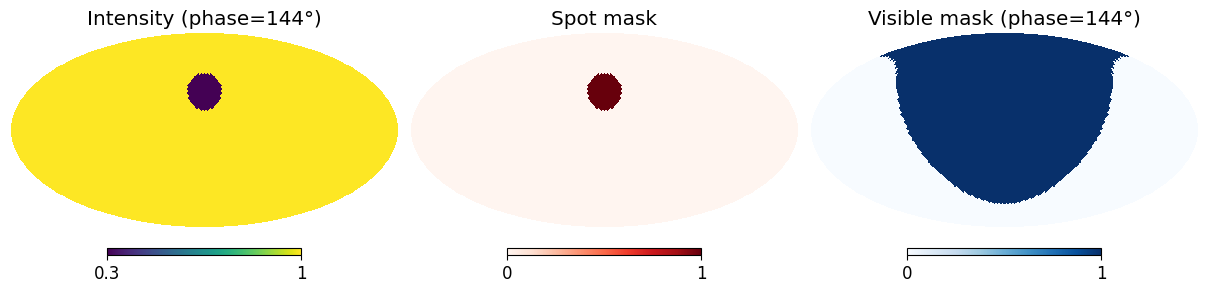

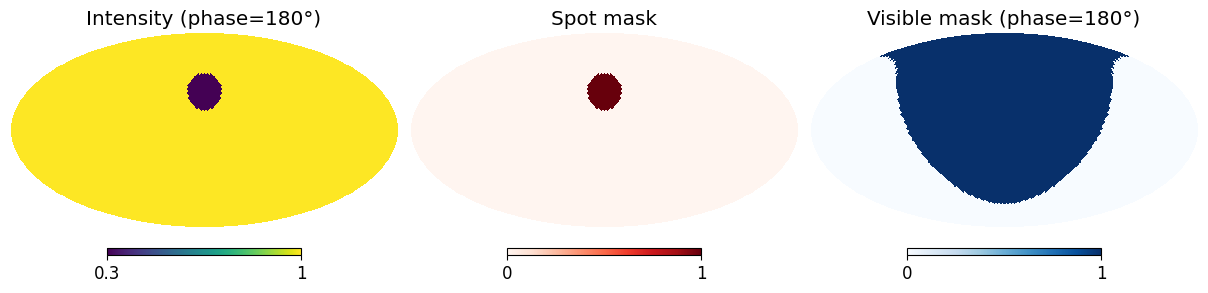

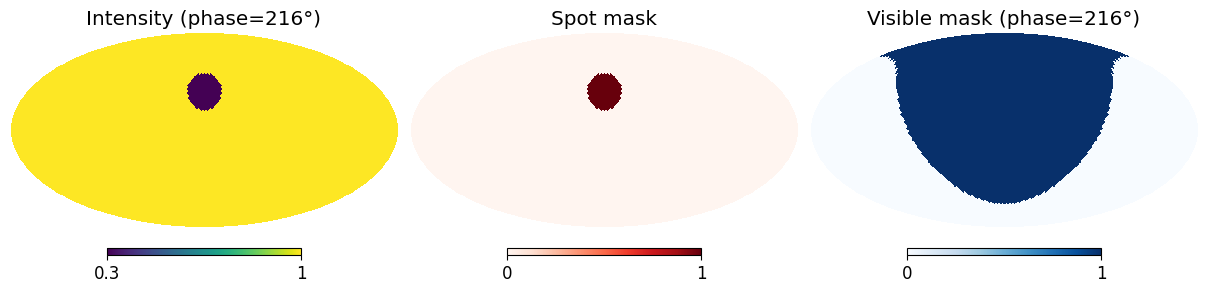

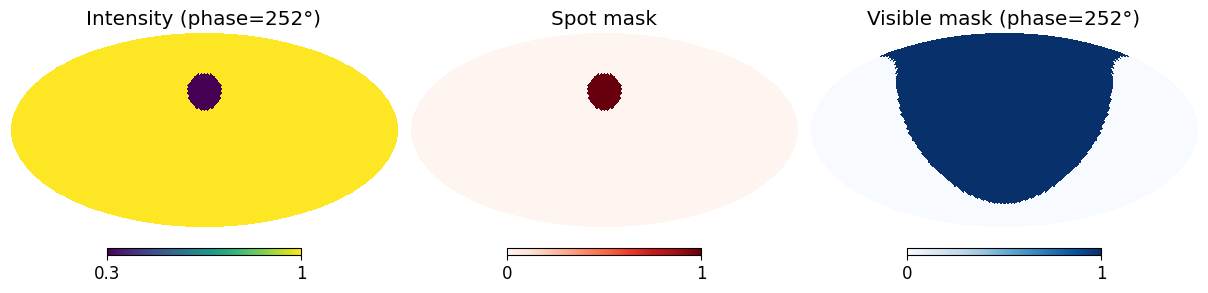

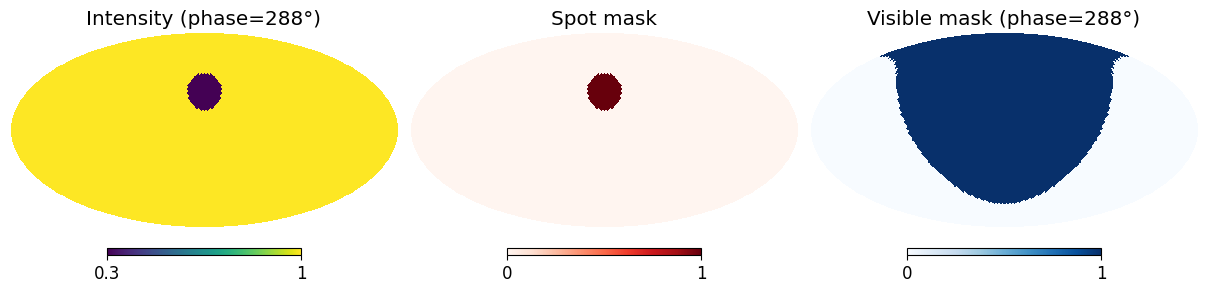

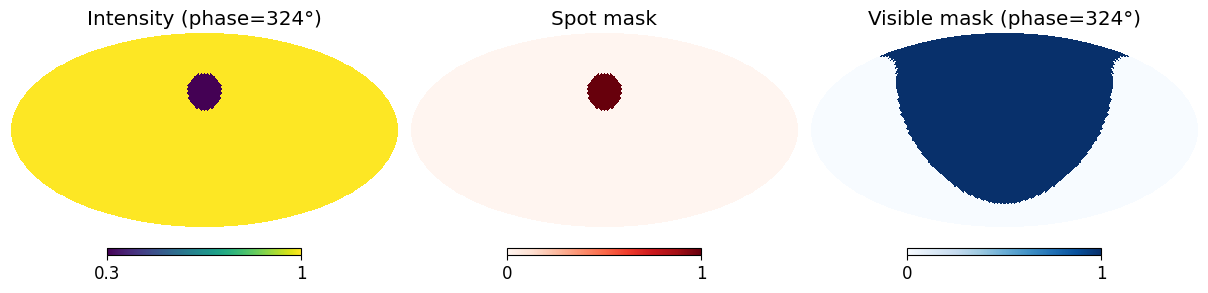

In [ ]:
# Compute the rotated visible‐hemisphere mask for 10 different rotation phases
import numpy as np
import healpy as hp

# Parameters
nside = 32
npix = hp.nside2npix(nside)
inc = 60.0  # inclination angle in degrees

# Precompute the original pixel coordinates
theta, phi = hp.pix2ang(nside, np.arange(npix))

# Helper function from above
def visible_mask(theta_array):
    return (theta_array <= np.pi / 2).astype(float)

# Choose 10 equally spaced rotation phases (in degrees)
phases = np.linspace(0, 360, 10, endpoint=False)

# Dictionary to hold the masks
vis_masks = {}

for ph in phases:
    # Build the same Rotator you use for the map
    rot = hp.Rotator(rot=[ph, inc, 0.0], deg=True, inv=True)

    # Rotate the pixel coordinates into the observer frame
    theta_r, phi_r = rot(theta, phi)

    # Compute the visible‐hemisphere mask at this phase
    vis_masks[ph] = visible_mask(theta_r)




# vis_masks now maps each phase (key) to a length-npix array of 0/1 values.
# For example, inspect the mask at phase=0° and phase=180°:
print("Visible mask fraction at phase 0°:",
      vis_masks[0.0].mean())
print("Visible mask fraction at phase 180°:",
      vis_masks[180.0].mean())


for ph, mask in vis_masks.items():
    # new figure for this phase
    plt.figure(figsize=(12, 4))

    # Panel 1: original brightness map
    hp.mollview(
        brightness,
        sub=(1, 3, 1),
        title=f"Intensity (phase={ph:.0f}°)",
        unit="",
        cmap="viridis",
        notext=True  # suppress the default title/label position so our title shows
    )

    # Panel 2: spot mask
    hp.mollview(
        mask_spot.astype(float),
        sub=(1, 3, 2),
        title="Spot mask",
        cmap="Reds",
        unit="",
        notext=True
    )

    # Panel 3: rotated visible mask
    hp.mollview(
        mask,
        sub=(1, 3, 3),
        title=f"Visible mask (phase={ph:.0f}°)",
        cmap="Blues",
        unit="",
        notext=True
    )

    plt.tight_layout()
    plt.show()


In [19]:
vis_masks.keys()

dict_keys([np.float64(0.0), np.float64(36.0), np.float64(72.0), np.float64(108.0), np.float64(144.0), np.float64(180.0), np.float64(216.0), np.float64(252.0), np.float64(288.0), np.float64(324.0)])

/var/folders/qq/_c3h3m7x0cj6f8qprnj5kyjw0000gq/T/ipykernel_24191/602234310.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


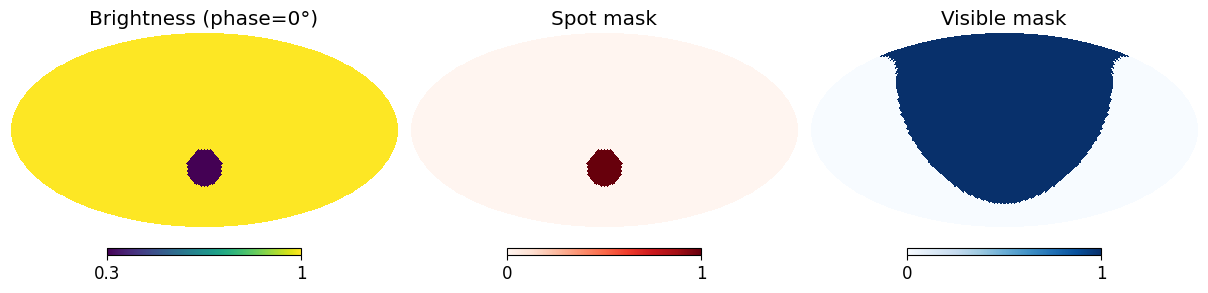

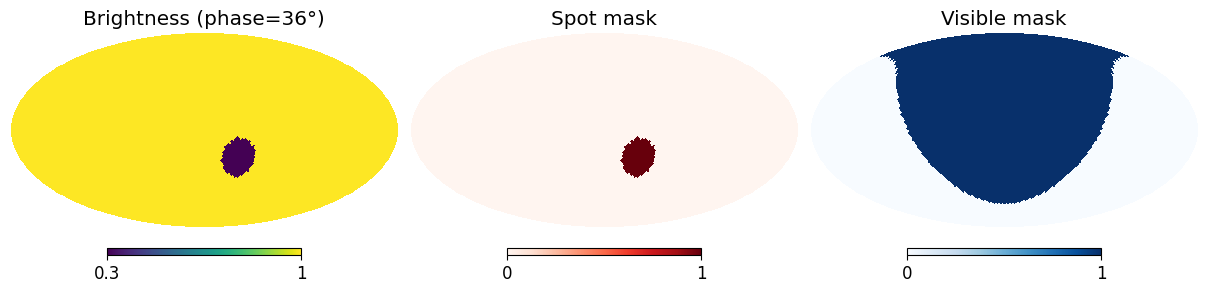

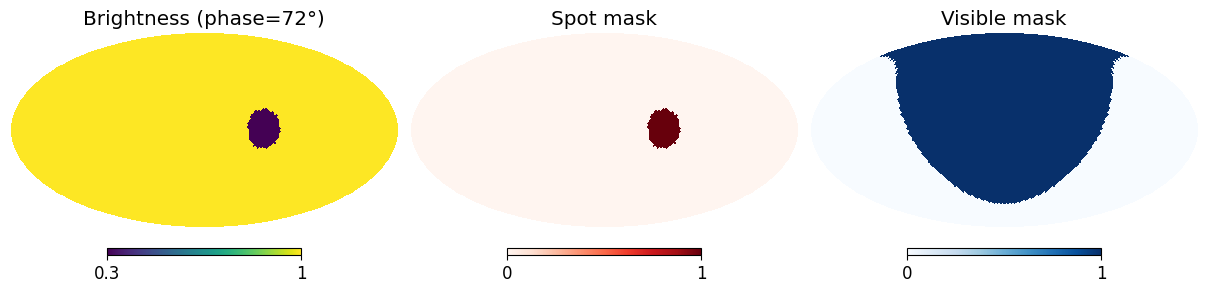

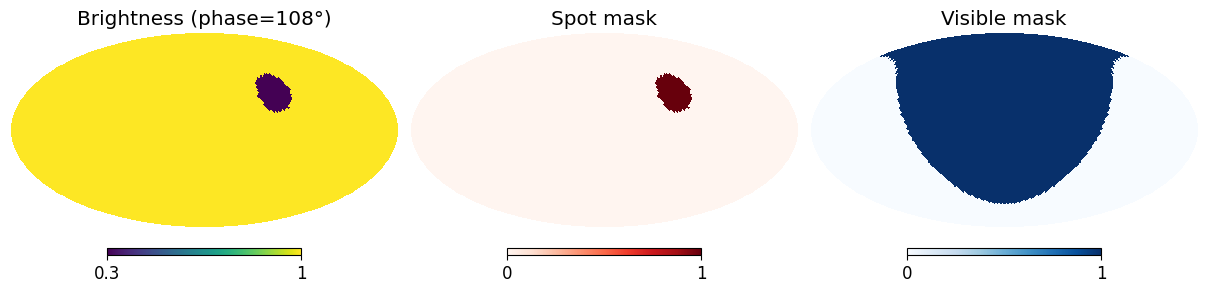

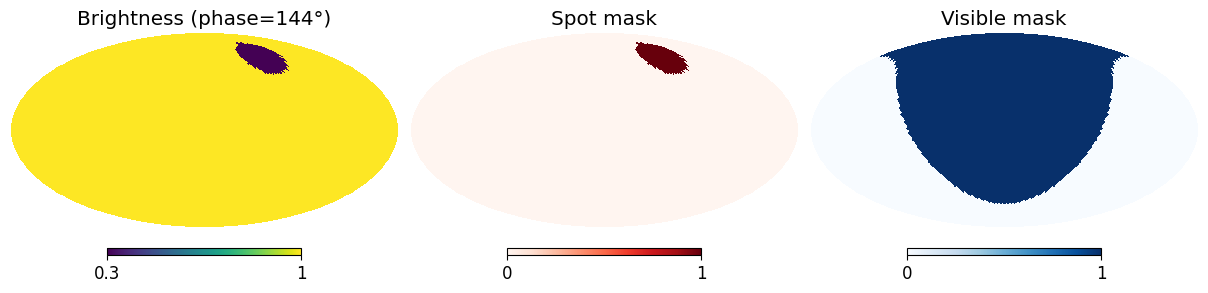

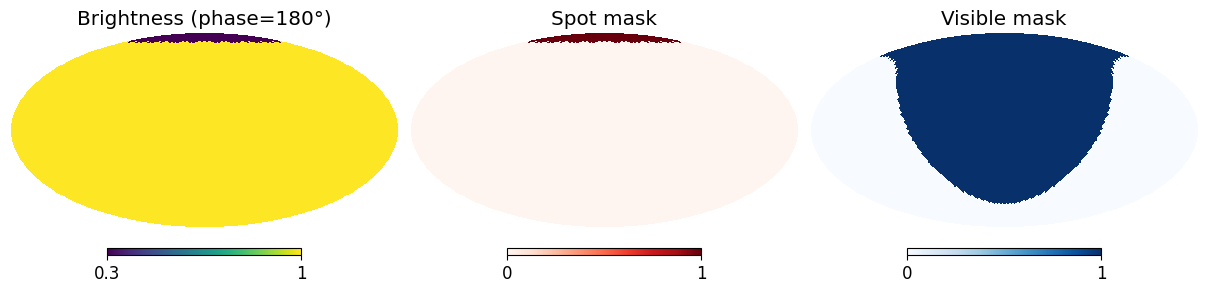

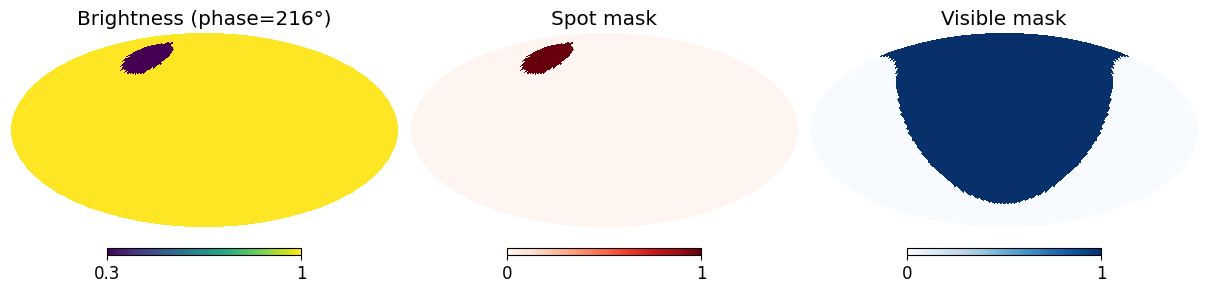

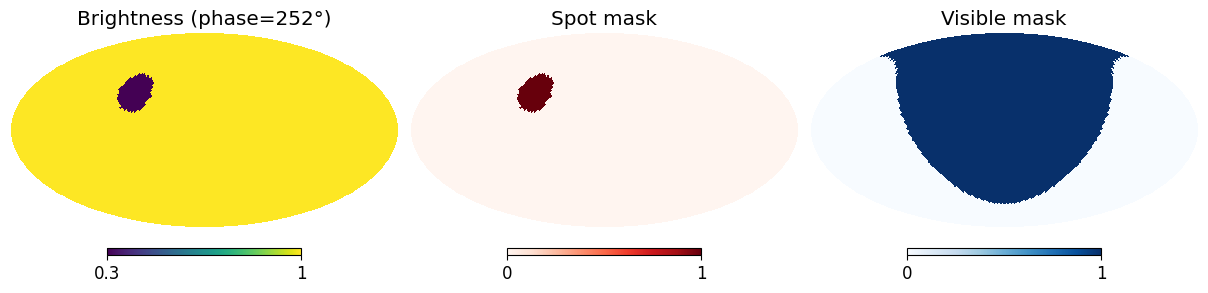

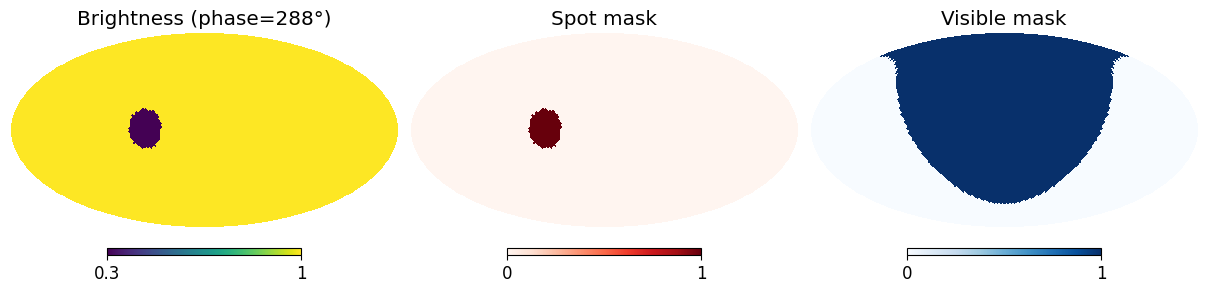

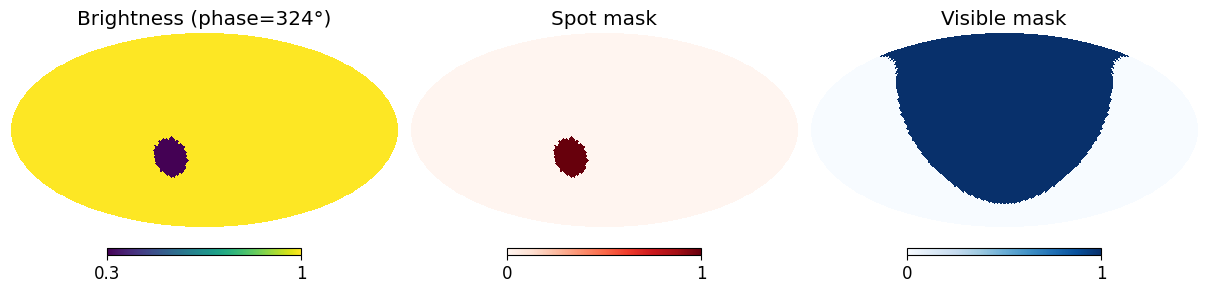

In [22]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# assume these are already defined:
# nside, brightness, mask_spot, inc, rotate_map, visible_mask

npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside, np.arange(npix))

# choose 10 phases
phases = np.linspace(0, 360, 10, endpoint=False)

for ph in phases:
    # 1) rotate the intensity map
    m_rot     = rotate_map(brightness,   inc, ph, nside)
    # 2) rotate the spot mask so you can see the spot move
    spot_rot  = rotate_map(mask_spot.astype(float), inc, ph, nside)

    # 3) compute the visible mask in the *rotated* frame
    rot       = hp.Rotator(rot=[ph, inc, 0.0], deg=True, inv=True)
    theta_r, _= rot(theta, phi)
    vis_rot   = visible_mask(theta_r)

    # now plot
    plt.figure(figsize=(12, 4))

    hp.mollview(
        m_rot,
        sub=(1, 3, 1),
        title=f"Brightness (phase={ph:.0f}°)",
        unit="",
        notext=True,
    )
    hp.mollview(
        spot_rot,
        sub=(1, 3, 2),
        title="Spot mask",
        cmap="Reds",
        unit="",
        notext=True,
    )
    hp.mollview(
        vis_rot,
        sub=(1, 3, 3),
        title="Visible mask",
        cmap="Blues",
        unit="",
        notext=True,
    )

    plt.tight_layout()
    plt.show()


/var/folders/qq/_c3h3m7x0cj6f8qprnj5kyjw0000gq/T/ipykernel_24191/330088540.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


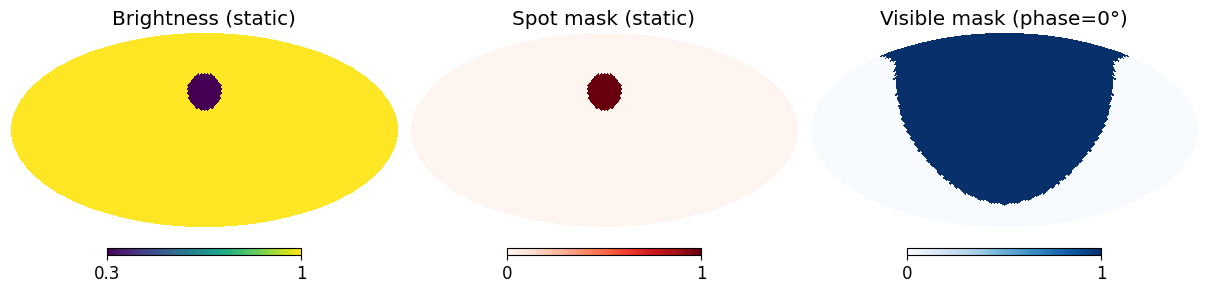

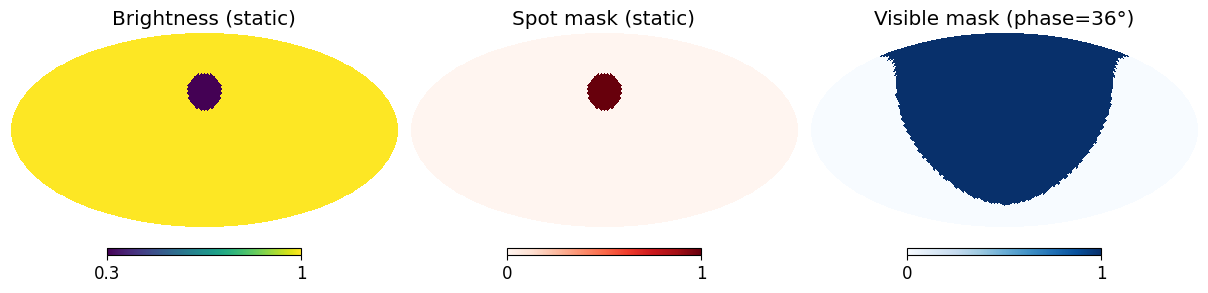

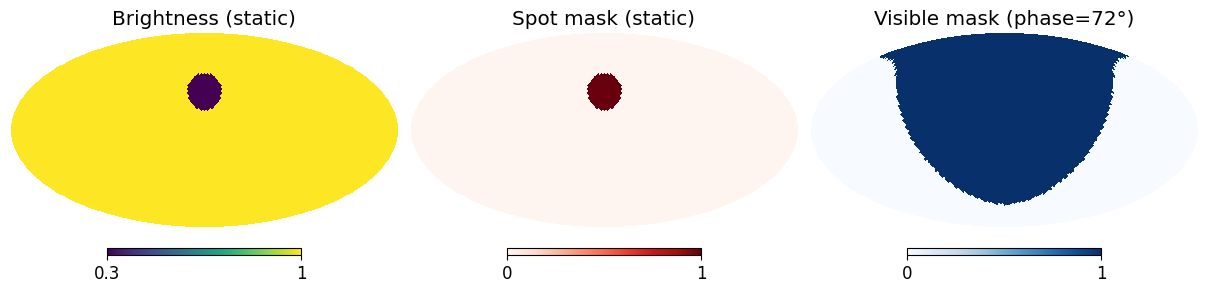

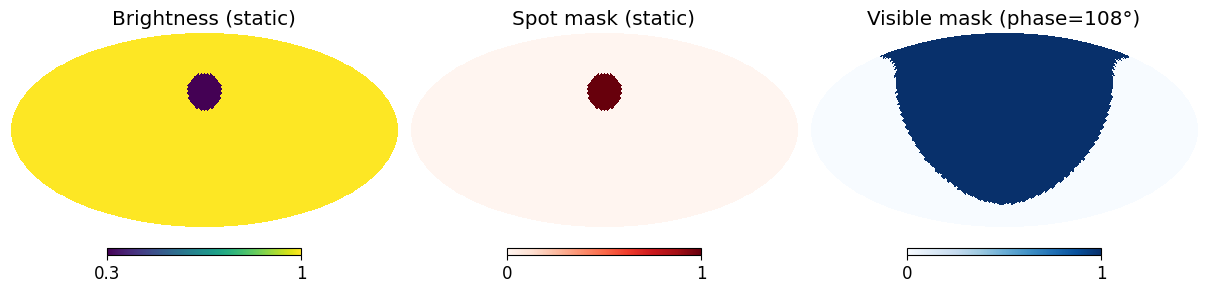

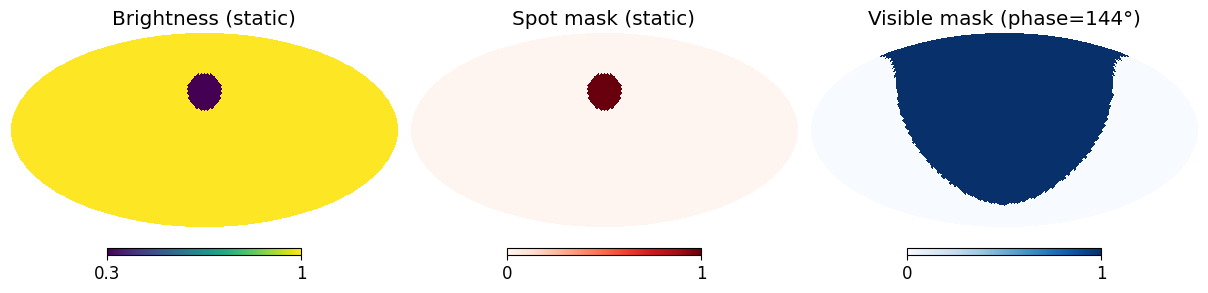

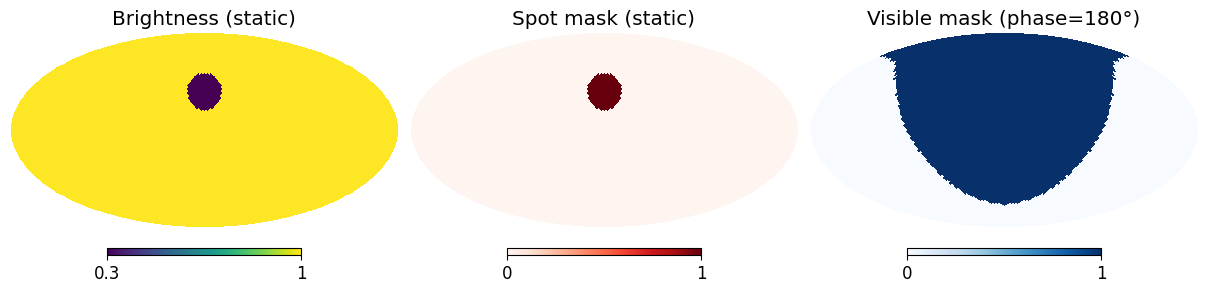

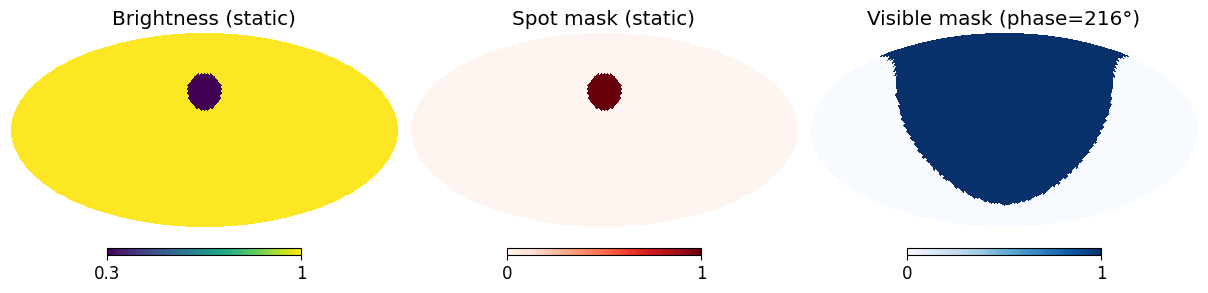

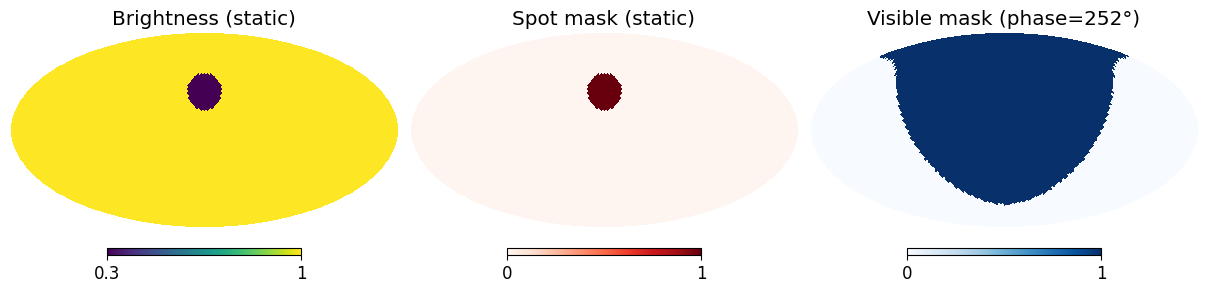

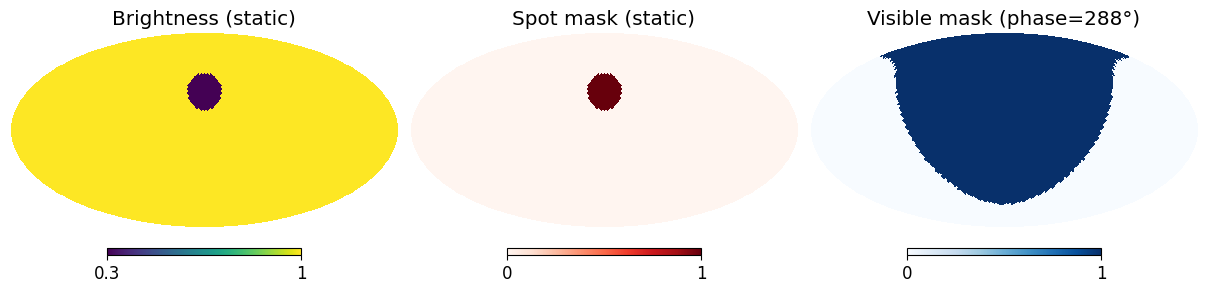

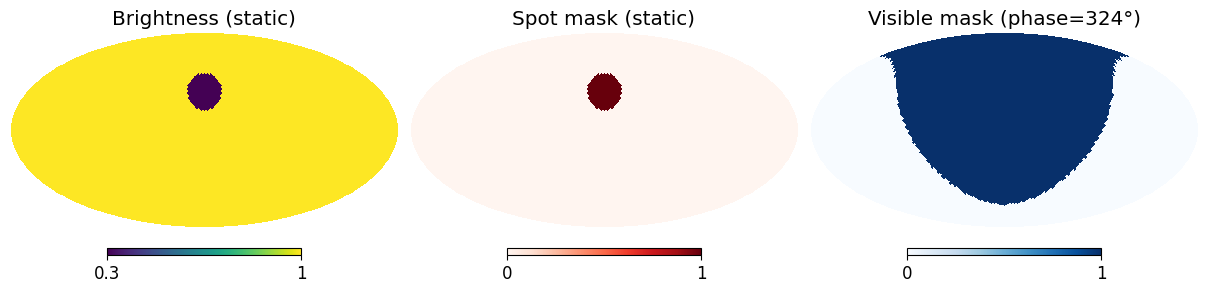

In [23]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# assume these are defined:
# nside, brightness, mask_spot, inc, rotate_map, visible_mask

npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside, np.arange(npix))

# 1) build a “base” visible mask for a pole-on star:
vis_base = visible_mask(theta)  # 1 for θ≤π/2, else 0

# 2) choose 10 phases
phases = np.linspace(0, 360, 10, endpoint=False)

for ph in phases:
    # rotate the mask (not the map!)
    mask_moving = rotate_map(vis_base, inc, ph, nside)

    plt.figure(figsize=(12, 4))

    # Panel 1: your static brightness+spot
    hp.mollview(
        brightness,
        sub=(1, 3, 1),
        title="Brightness (static)",
        unit="",
        notext=True,
    )
    hp.mollview(
        mask_spot.astype(float),
        sub=(1, 3, 2),
        title="Spot mask (static)",
        cmap="Reds",
        unit="",
        notext=True,
    )

    # Panel 3: the moving visible mask
    hp.mollview(
        mask_moving,
        sub=(1, 3, 3),
        title=f"Visible mask (phase={ph:.0f}°)",
        cmap="Blues",
        unit="",
        notext=True,
    )

    plt.tight_layout()
    plt.show()
